In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import matplotlib.colors as mlc
from matplotlib.ticker import AutoMinorLocator
from pathlib import Path


In [9]:
OUTPUT_DIR = "outputs"

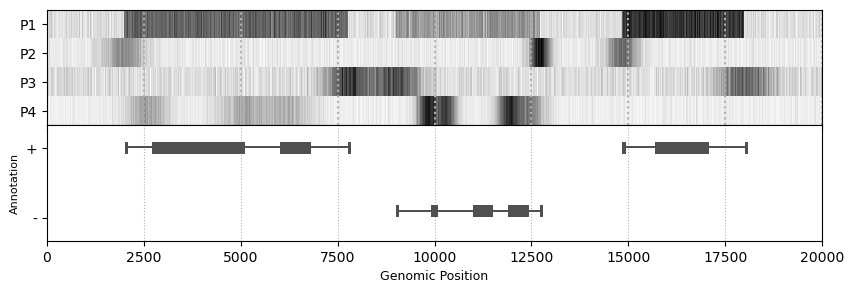

In [14]:
#creating figures and axes and aligning then with no space in between sharing the same x-axis
fig, ax = plt.subplots(2,1, sharex=True)
fig.set_size_inches (10,3)
fig.subplots_adjust(hspace=0)


#creating the upper plot
signal_array = np.array([signals["P1"], signals["P2"], signals["P3"], signals["P4"]])
ax[0].imshow(signal_array, cmap= "Greys", aspect = "auto", interpolation = "none")
ax[0].set_yticks([0, 1, 2, 3], labels=["P1", "P2", "P3", "P4"])
ax[0].grid(axis = "x", linestyle = "dotted", linewidth = 1.5)


#adjusting the lower plot
ax[1].set_xlim(0,20000)
ax[1].set_yticks([0.2, 0.8], labels = ("-", "+"))
ax[1].grid(axis = "x", linestyle = "dotted", linewidth = 0.8, zorder=1)
ax[1].set_ylabel("Annotation", fontsize = 8)
ax[1].set_xlabel("Genomic Position", fontsize = 9)


#creating list capturing all figures in annotation plot
annotation_figures = []

#iterating over each row in annotation to get the length
for i in annotation.index:
    start = annotation["start"].iloc[i]
    stop = annotation["stop"].iloc[i]
    length = stop - start
    
    #postisioning each strand
    if annotation["strand"].iloc[i] == "+":
        strand = 0.8
    else:
        strand = 0.25
    
    #drawing figures for start, end and whole transcript using if statement
    if annotation["type"].iloc[i] == "transcript":
        transcript_line = patches.Rectangle((start, strand), length, 0.02, facecolor="#505050", zorder=3)
        annotation_figures.append(transcript_line)
        start_figure = patches.Rectangle((start, strand - 0.045), 90, 0.1, facecolor="#505050", zorder=3)
        annotation_figures.append(start_figure)
        end_figure = patches.Rectangle((stop, strand - 0.045), 90, 0.1, facecolor="#505050", zorder=3)
        annotation_figures.append(end_figure)
    
    # else statement used to draw exons     
    else:
        exons = patches.Rectangle((start, strand - 0.045 ), length, 0.1, facecolor="#505050", zorder=3)
        annotation_figures.append(exons)
    
# adding all annotation figures to the annotation plot
for figure in annotation_figures:
    ax[1].add_patch(figure)


plt.savefig(f"{OUTPUT_DIR}/genomic_signals_annotation.png", dpi=300, bbox_inches="tight")

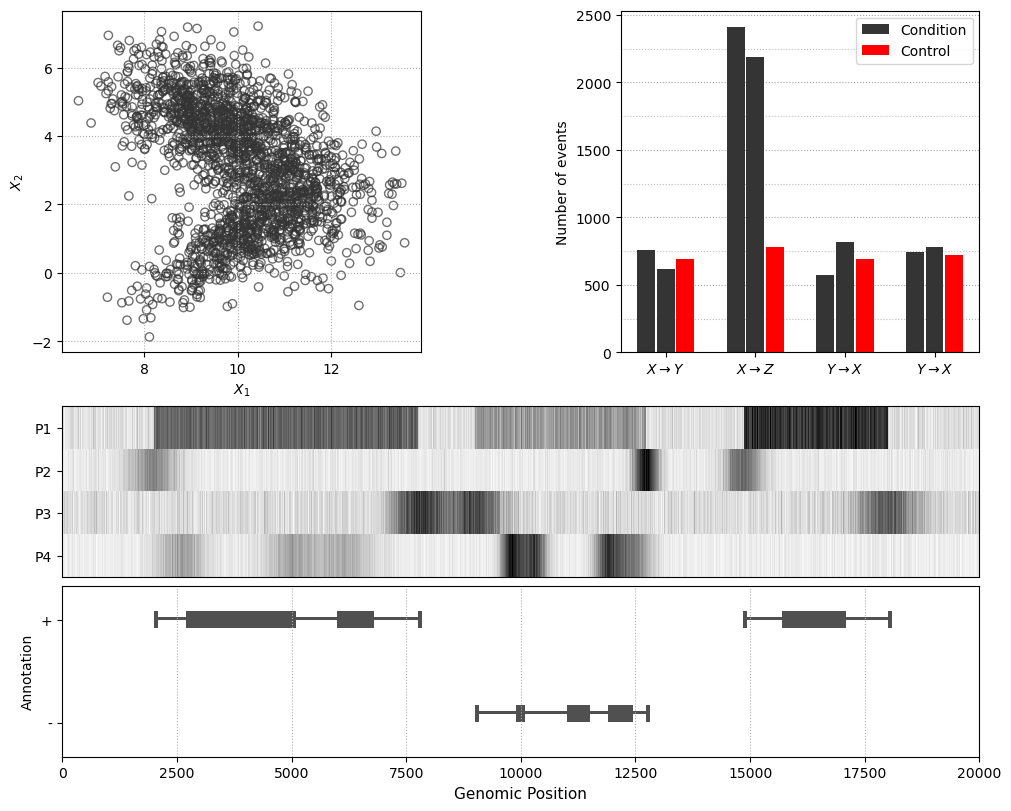

In [15]:
#reading scatterplot and barplot data
scatterplot_data = pd.read_csv("data/10_project_data_scatter.csv")
barplot_data = pd.read_csv("data/10_project_data_barplot.csv")


#creating layout and adjusting grid ratios
fig = plt.figure(constrained_layout=True)
fig.set_size_inches(10,8)
gs = fig.add_gridspec(3, 9,height_ratios=[1, 0.5, 0.5])  # Adjust height ratios for flexibility


#assigning each plot to its specific place
#on the layout
scatterplot = fig.add_subplot(gs[0, 0:4])  
barplot = fig.add_subplot(gs[0, 5:9])  
heatmap = fig.add_subplot(gs[1, :])
annotationplot = fig.add_subplot(gs[2, :])


#creating scatterplot
scatterplot.scatter(scatterplot_data["x1"], scatterplot_data["x2"], facecolor="none", edgecolor="#343434", alpha=0.7)
scatterplot.set_xlabel(r"$X_{1}$")
scatterplot.set_ylabel(r"$X_{2}$")
scatterplot.grid(linestyle = "dotted")
scatterplot.set_xticks([8, 10, 12])


#creating barplot
x = np.arange(len(barplot_data.columns))
bar_width = 0.2
barplot.bar(x - 0.22, barplot_data["condition_a_sample_1"], width=bar_width, color="#343434", zorder=2, label = "Condition")
barplot.bar(x, barplot_data["condition_a_sample_2"], width=bar_width, color="#343434", zorder=2)
barplot.bar(x + 0.22, barplot_data["control"], width=bar_width, color="Red", zorder=2, label = "Control")
barplot.set_ylabel("Number of events")
barplot.set_xticks(x, [r"$X \rightarrow Y$" , r"$X \rightarrow Z$", r"$Y \rightarrow X$", r"$Y \rightarrow X$"])
barplot.yaxis.set_minor_locator(AutoMinorLocator(2))
barplot.grid(axis='y', which='minor', linestyle='dotted', color='gray', alpha=0.5, zorder=0)
barplot.grid(axis='y', linestyle='dotted', color='gray', alpha=0.7, zorder=0)
barplot.tick_params(axis='y', which='minor', length=0)
barplot.legend(loc= "upper right", prop = { "size": 10 })


#recreating heatmap
heatmap.imshow(signal_array, cmap= "Greys", aspect = "auto", interpolation = "none")
heatmap.set_yticks([0, 1, 2, 3], labels=["P1", "P2", "P3", "P4"])
heatmap.tick_params(axis='x',which = "major", length = 0, labelbottom= False)


#recreating annotation plot
annotationplot.set_xlim(0,20000)
annotationplot.set_yticks([0.2, 0.8], labels = ("-", "+"))
annotationplot.grid(axis = "x", linestyle = "dotted", linewidth = 0.8, zorder=1)
annotationplot.set_ylabel("Annotation", fontsize = 10)
annotationplot.set_xlabel("Genomic Position", fontsize = 11)

#creating list capturing all figures in annotation plot
annotation_figures = []
for i in annotation.index:
    start = annotation["start"].iloc[i]
    stop = annotation["stop"].iloc[i]
    length = stop - start
    
    #postisioning each strand
    if annotation["strand"].iloc[i] == "+":
        strand = 0.8
    else:
        strand = 0.25
    
    #drawing figures for start, end and whole transcript using if statement
    if annotation["type"].iloc[i] == "transcript":
        transcript_line = patches.Rectangle((start, strand), length, 0.02, facecolor="#505050", zorder=1)
        annotation_figures.append(transcript_line)
        start_figure = patches.Rectangle((start, strand - 0.045), 90, 0.1, facecolor="#505050", zorder=1)
        annotation_figures.append(start_figure)
        end_figure = patches.Rectangle((stop, strand - 0.045), 90, 0.1, facecolor="#505050", zorder=1)
        annotation_figures.append(end_figure)
    
    # else statement used to draw exons     
    else:
        exons = patches.Rectangle((start, strand - 0.045 ), length, 0.1, facecolor="#505050", zorder=1)
        annotation_figures.append(exons)

# adding all annotation figures to the annotation plot
for figure in annotation_figures:
    annotationplot.add_patch(figure)



plt.savefig(f"{OUTPUT_DIR}/annotation_composita_figures.png", dpi=300, bbox_inches="tight")

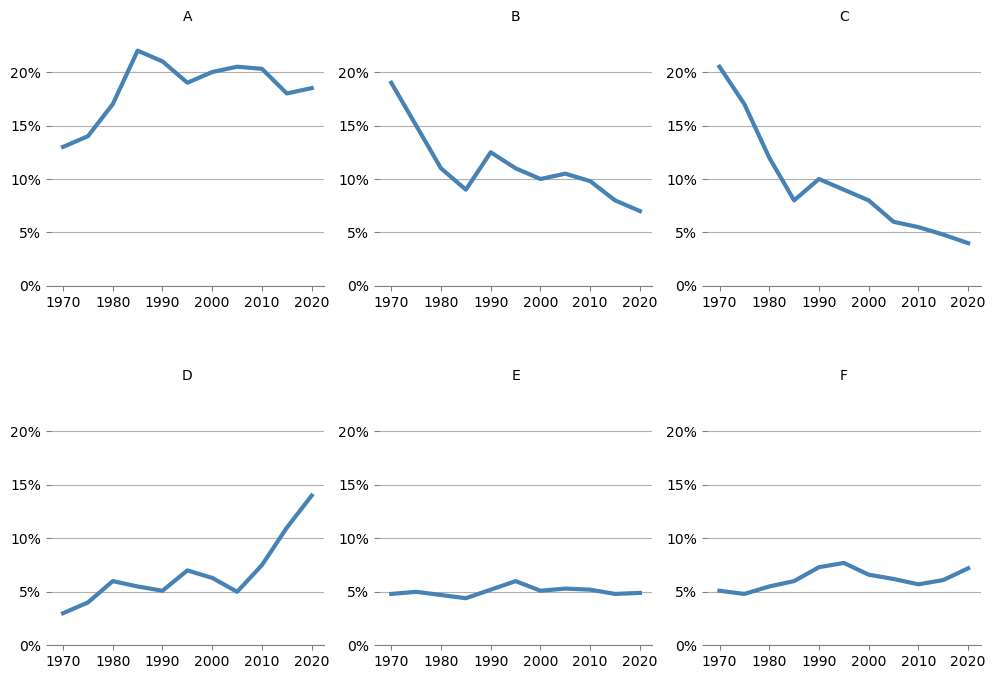

In [16]:
#reading in data
lineplot = pd.read_csv("data/10_project_data_lineplots.csv")

#creating plots
fig, ax = plt.subplots(2,3)
fig.set_size_inches(12,8)
fig.subplots_adjust(hspace=0.4)

#creaing list of all columns names
line_columns = list(lineplot.columns)


#setting range for y-axis ticks
yticks = np.arange(0, 25, 5)

#k variable to assign a column to each graph
k = 0

#nested loop to create all graphs since all have the same adjustments
for i in range(2):
    for j in range(3):
        ax[i][j].plot(lineplot['years'], lineplot[line_columns[k+1]], color="SteelBlue", linewidth=3)
        ax[i][j].set_ylim(0,24)
        ax[i][j].set_yticks(yticks)
        ax[i][j].set_yticklabels([f'{int(tick)}%' for tick in yticks])
        ax[i][j].grid(axis = "y")
        ax[i][j].spines["top"].set_visible(False)
        ax[i][j].spines["right"].set_visible(False)
        ax[i][j].spines["left"].set_visible(False)
        ax[i][j].spines["bottom"].set_color("gray")
        ax[i][j].tick_params(axis='x', color = "gray")
        ax[i][j].tick_params(axis='y', color = "gray")
        ax[i][j].set_title(line_columns[k+1], fontsize = 10)
        k += 1


plt.savefig(f"{OUTPUT_DIR}/trends_figures.png", dpi=300, bbox_inches="tight")

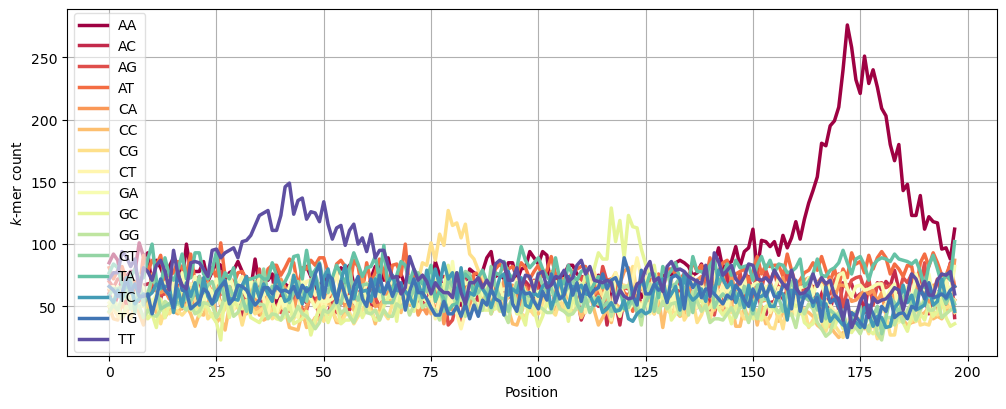

In [18]:
#reading in data 
with open('data/10_project_data_dna_sequences.txt', 'r') as file:
    sequences = [line.strip() for line in file]


#creating a list of all four bases
#creatimg k-mers list containing all 16 2-mers combinations using a loop
bases = ["A", "C", "G", "T"]
k_mers = []
for i in bases:
    for j in bases:
        k_mers.append(i+j)

"""
since all sequences are of the same length (used for loop to determine lengths)
i created a dicctionary positions to hold k_mers as keys and initiated values of zeroes 
equal to the length of the sequences.
using nested loop to iterate over the sequences and indicies to capture the postion
of each k_mer then incrementing the counts of the corresponding value in each key 
"""

positions = {k_mer: np.zeros(200) for k_mer in k_mers}   
for sequence in sequences:
    for pos in range(len(sequence) - 1):
        k_mer = sequence[pos:pos + 2]
        positions[k_mer][pos] += 1


#creating a plot and applying color map with range 16
fig, ax = plt.subplots()
fig.set_size_inches(12, 4.5)
colormap = plt.get_cmap("Spectral",16)  
rgbacolors = colormap(range(16))


#looping to create the desired plot using i to assign the colors of each key
for i, (key, value) in enumerate(positions.items()):
    ax.plot(value[:198] , color= rgbacolors[i], label = key, linewidth = 2.5)
    

#adjusting the plot
ax.grid()
ax.legend(loc = "center left", framealpha = 0.6)
ax.set_xlabel("Position")
ax.set_ylabel(r"$k$-mer count")




plt.savefig(f"{OUTPUT_DIR}/kmers_distribution.png", dpi=300, bbox_inches="tight")
plt.show()